# Fake News Classifier
### Logistic Regression vs Naive Bayes | TF-IDF vs BOW | Lemmatization

**Workflow:**
1. Data inladen
2. Train/Test split
3. Preprocessing
4. Feature Extraction (TF-IDF en BOW)
5. Modellen trainen (LR en NB)
6. Evaluatie en visualisatie
7. Voorspellingen op nieuwe data

## STAP 1 - Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Setup ready!')

Setup ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## STAP 2 - Data inladen en bekijken

In [2]:
df = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/training_data_fixed.csv')

print('Shape:', df.shape)
print('Lege waarden:', df.isnull().sum().to_dict())
print('Klasse verdeling:')
print(df['label'].value_counts())
df.head()

Shape: (34152, 2)
Lege waarden: {'label': 0, 'text': 0}
Klasse verdeling:
label
0    17572
1    16580
Name: count, dtype: int64


,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


## STAP 3 - Train/Test Split
**Belangrijk:** split VOOR preprocessing zodat testdata echt ongezien blijft!

In [3]:
df.fillna('', inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

print('Train:', X_train.shape[0], 'samples')
print('Test: ', X_test.shape[0], 'samples')

Train: 27321 samples
Test:  6831 samples


## STAP 4 - Preprocessing
Data is al lowercase, geen HTML. Stappen: special chars → tokenization → stopwords → lemmatization

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Special characters verwijderen
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Losse letters en dubbele spaties
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization
    tokens = word_tokenize(text)
    # Punctuation removal
    tokens = [w for w in tokens if w not in string.punctuation]
    # Stopwords removal
    tokens = [w for w in tokens if w not in stop_words]
    # Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Toepassen op train en test APART
X_train = X_train.apply(preprocess)
X_test  = X_test.apply(preprocess)

# Visuele check voor vs na preprocessing
print('VOOR:', df['text'].loc[X_train.index[1]])
print('NA:  ', X_train.values[1])

VOOR: final reckoning approaches for obama's high court nominee
NA:   final reckoning approach obama high court nominee


## STAP 5 - Feature Extraction
**fit_transform op train** → leert vocabulaire  
**transform op test** → gebruikt ZELFDE vocabulaire, NOOIT fit_transform op testdata!

In [14]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# BOW
cv = CountVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_bow = cv.fit_transform(X_train)
X_test_bow  = cv.transform(X_test)

print('TF-IDF shape:', X_train_tfidf.shape)
print('BOW shape:   ', X_train_bow.shape)

TF-IDF shape: (27321, 20000)
BOW shape:    (27321, 20000)


## STAP 6 - Modellen Trainen en Evalueren

In [15]:
# Alle 4 modellen trainen en evalueren
modellen = {
    'LR + TF-IDF':  (LogisticRegression(max_iter=1000), X_train_tfidf, X_test_tfidf),
    'NB + TF-IDF':  (MultinomialNB(),                   X_train_tfidf, X_test_tfidf),
    'LR + BOW':     (LogisticRegression(max_iter=1000), X_train_bow,   X_test_bow),
    'NB + BOW':     (MultinomialNB(),                   X_train_bow,   X_test_bow),
}

resultaten = {}
getrainde_modellen = {}

for naam, (model, X_tr, X_te) in modellen.items():
    model.fit(X_tr, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc  = accuracy_score(y_test,  model.predict(X_te))
    resultaten[naam] = (train_acc, test_acc)
    getrainde_modellen[naam] = model
    print(f'{naam:15} → Train: {train_acc:.3f} | Test: {test_acc:.3f} | Verschil: {abs(train_acc-test_acc):.3f}')

LR + TF-IDF     → Train: 0.960 | Test: 0.933 | Verschil: 0.027
NB + TF-IDF     → Train: 0.954 | Test: 0.930 | Verschil: 0.024
LR + BOW        → Train: 0.984 | Test: 0.941 | Verschil: 0.043
NB + BOW        → Train: 0.953 | Test: 0.933 | Verschil: 0.021


## STAP 7 - Visualisatie

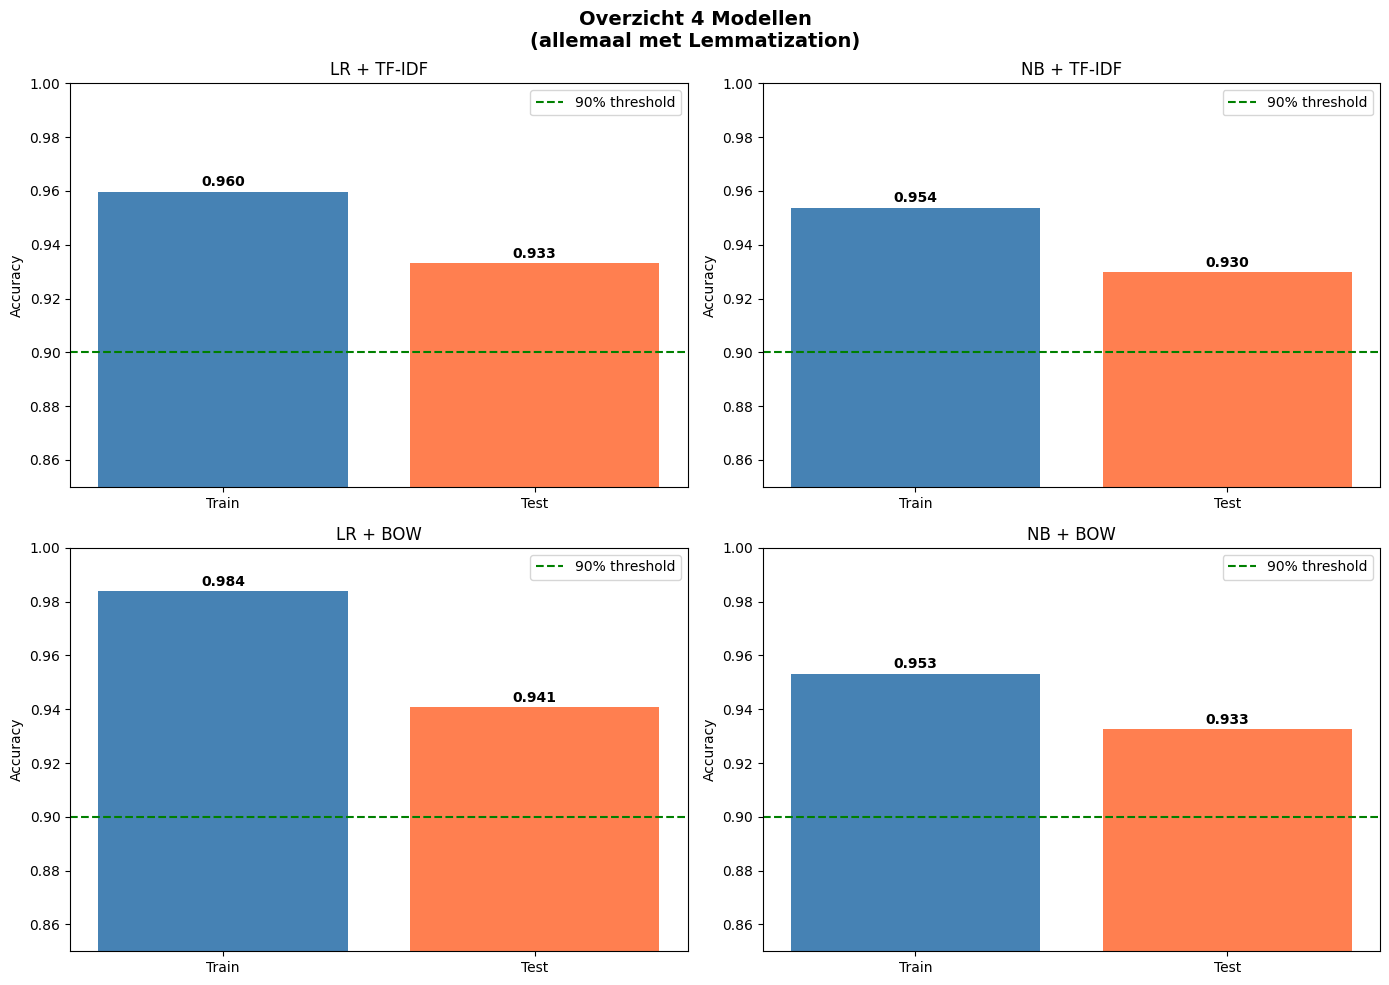

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (naam, (train_acc, test_acc)) in enumerate(resultaten.items()):
    axes[i].bar(['Train', 'Test'], [train_acc, test_acc], color=['steelblue', 'coral'])
    axes[i].set_title(naam)
    axes[i].set_ylabel('Accuracy')
    axes[i].set_ylim(0.85, 1.0)
    axes[i].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
    for j, v in enumerate([train_acc, test_acc]):
        axes[i].text(j, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')
    axes[i].legend()

plt.suptitle('Overzicht 4 Modellen\n(allemaal met Lemmatization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Classification Report: LR + BOW ===
              precision    recall  f1-score   support

    Fake (0)       0.95      0.94      0.94      3529
    Real (1)       0.93      0.95      0.94      3302

    accuracy                           0.94      6831
   macro avg       0.94      0.94      0.94      6831
weighted avg       0.94      0.94      0.94      6831



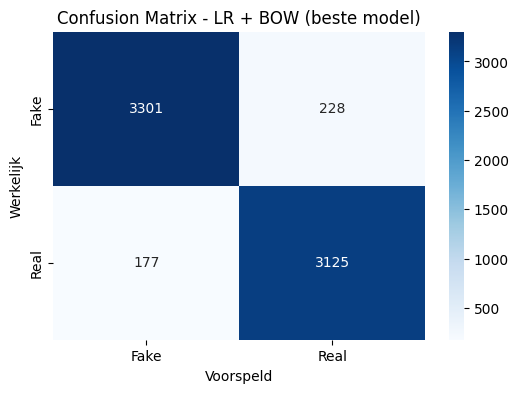

In [17]:
# Classification report beste model (LR + BOW)
best_model = getrainde_modellen['LR + BOW']
y_pred_best = best_model.predict(X_test_bow)

print('=== Classification Report: LR + BOW ===')
print(classification_report(y_test, y_pred_best, target_names=['Fake (0)', 'Real (1)']))

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - LR + BOW (beste model)')
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijk')
plt.show()

## STAP 8 - Voorspellingen op nieuwe testdata (Kaggle submission)

In [20]:
# Laad nieuwe testdata
df_new = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/testing_data_lowercase_nolabels.csv',
                     header=None, sep='\t', names=['id', 'text'])

# Preprocessing - zelfde functie als traindata!
df_new['text'] = df_new['text'].apply(preprocess)

# Transformeer met ZELFDE vectorizer - NOOIT fit_transform!
X_new = cv.transform(df_new['text'])

# Voorspel met beste model
df_new['label'] = best_model.predict(X_new)

print('Voorspelling verdeling:')
print(df_new['label'].value_counts())
print(f'\nFake: {(df_new["label"]==0).sum()} ({(df_new["label"]==0).mean()*100:.1f}%)')
print(f'Real: {(df_new["label"]==1).sum()} ({(df_new["label"]==1).mean()*100:.1f}%)')

# Opslaan voor submission
df_new[['id', 'label']].to_csv('submission.csv', index=False)
print('\nOpgeslagen als submission.csv')

df_new.head()

Voorspelling verdeling:
label
1    5243
0    4741
Name: count, dtype: int64

Fake: 4741 (47.5%)
Real: 5243 (52.5%)

Opgeslagen als submission.csv


,id,text,label
0,2,copycat muslim terrorist arrested assault weapon,0
1,2,wow chicago protester caught camera admits vio...,0
2,2,germany fdp look fill schaeuble big shoe,1
3,2,mi school sends welcome back packet warning ki...,0
4,2,seek massive aid boost amid rohingya emergency...,1


## STAP 9 - Model opslaan

In [19]:
# Beste model en vectorizer opslaan
with open('model_lr_bow.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('vectorizer_bow.pkl', 'wb') as f:
    pickle.dump(cv, f)

print('Model en vectorizer opgeslagen!')

Model en vectorizer opgeslagen!


###Cross-validation

In [21]:
from sklearn.model_selection import cross_val_score

modellen_cv = {
    'LR + TF-IDF': (LogisticRegression(max_iter=1000), X_train_tfidf),
    'NB + TF-IDF': (MultinomialNB(),                   X_train_tfidf),
    'LR + BOW':    (LogisticRegression(max_iter=1000), X_train_bow),
    'NB + BOW':    (MultinomialNB(),                   X_train_bow),
}

cv_resultaten = {}

for naam, (model, X_tr) in modellen_cv.items():
    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')
    cv_resultaten[naam] = scores
    print(f'{naam:15} → Gemiddelde: {scores.mean():.3f} | Std: {scores.std():.3f} | Scores: {scores.round(3)}')

LR + TF-IDF     → Gemiddelde: 0.932 | Std: 0.004 | Scores: [0.937 0.926 0.93  0.93  0.935]
NB + TF-IDF     → Gemiddelde: 0.932 | Std: 0.004 | Scores: [0.935 0.925 0.932 0.929 0.936]
LR + BOW        → Gemiddelde: 0.936 | Std: 0.003 | Scores: [0.941 0.932 0.938 0.932 0.936]
NB + BOW        → Gemiddelde: 0.934 | Std: 0.004 | Scores: [0.937 0.929 0.932 0.933 0.939]


In [22]:
from sklearn.ensemble import RandomForestClassifier

modellen_rf = {
    'RF + TF-IDF': (RandomForestClassifier(n_estimators=100, random_state=42), X_train_tfidf, X_test_tfidf),
    'RF + BOW':    (RandomForestClassifier(n_estimators=100, random_state=42), X_train_bow,   X_test_bow),
}

for naam, (model, X_tr, X_te) in modellen_rf.items():
    model.fit(X_tr, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc  = accuracy_score(y_test,  model.predict(X_te))
    print(f'{naam} → Train: {train_acc:.3f} | Test: {test_acc:.3f} | Verschil: {abs(train_acc-test_acc):.3f}')

RF + TF-IDF → Train: 1.000 | Test: 0.916 | Verschil: 0.084
RF + BOW → Train: 1.000 | Test: 0.915 | Verschil: 0.085


In [23]:
from xgboost import XGBClassifier

modellen_xgb = {
    'XGB + TF-IDF': (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), X_train_tfidf, X_test_tfidf),
    'XGB + BOW':    (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), X_train_bow,   X_test_bow),
}

for naam, (model, X_tr, X_te) in modellen_xgb.items():
    model.fit(X_tr, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc  = accuracy_score(y_test,  model.predict(X_te))
    print(f'{naam} → Train: {train_acc:.3f} | Test: {test_acc:.3f} | Verschil: {abs(train_acc-test_acc):.3f}')

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/opt/homebrew/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /opt/homebrew/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew